In [8]:
import pandas as pd 
import requests
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.outliers_influence import variance_inflation_factor
from patsy import dmatrix
import statsmodels.formula.api as smf

In [9]:
data = pd.read_csv("data/orders-2026-04-04-19-54-54.csv")
data["Order Date"] = pd.to_datetime(data["Order Date"])
data["date"] = data["Order Date"].dt.date
data["day_of_week"] = data["Order Date"].dt.day_name()

In [10]:
orders = pd.read_csv("data/orders-2026-04-04-19-54-54.csv")
gender = pd.read_csv("data/orders_with_gender.csv")[["Order Number", "gender"]]

data = orders.merge(gender, on="Order Number", how="left")

data.head()

,Order Number,Order Date,First Name (Billing),Last Name (Billing),Order Total Amount,Store Location,Email (Billing),Item #,Item Name,Quantity (- Refund),Item Cost,gender
0,10529,2026-04-04 19:44,Оксана,Мельник,77.0,k1kvasiukiv,oksana.melnyk6g@gmail.com,1,"PRINGLES зі смаком ""Паприка"" (маленькі)",1,77.0,female
1,10528,2026-04-04 19:37,Магдалина,Федаш,53.0,k1kvasiukiv,magdalusic@gmail.com,1,BUENO Kinder,1,53.0,female
2,10527,2026-04-04 19:37,Ольга,Димінська,69.0,studprostir,dyminska.nz@ucu.edu.ua,1,CHIPSTER'S зі смаком Сметана та цибуля,1,69.0,female
3,10526,2026-04-04 19:21,Evhenia,Shymon,34.0,k2melnykiv,pick.patsy_8u@icloud.com,1,"Coca Cola 0,33л",1,34.0,female
4,10525,2026-04-04 19:16,Софія,Димінська,37.0,k1mysiakovskoho,dyminskasofia@gmail.com,1,"FUZE Tea ""Персик"" 0,5л",1,37.0,female


In [11]:
data["Order Date"] = pd.to_datetime(data["Order Date"])
data["date"] = data["Order Date"].dt.date
data["day_of_week"] = data["Order Date"].dt.day_name()

female_per_day = (
    data[data["gender"] == "female"]
    .groupby(["date", "Store Location"])
    .agg(female_count=("Order Number", "count"))
    .reset_index()
    .rename(columns={"Store Location": "store_location"})
)

total_orders = (
    data.groupby(["date", "Store Location"])
    .agg(total_orders=("Order Number", "nunique"))
    .reset_index()
    .rename(columns={"Store Location": "store_location"})
)
sweets = [
    'BUENO Kinder',
    'KINDER Chocolate 4шт',
    'KINDER Chocolate 8шт',
    'MARS',
    'SNICKERS',
    'TWIX'
]

sweets_df = data[data["Item Name"].isin(sweets)]

sweets_freq = (
    sweets_df.groupby(["date", "day_of_week", "Store Location"])
    .agg(purchase_count=("Order Number", "nunique"))
    .reset_index()
)

all_dates = data[["date", "day_of_week", "Store Location"]].drop_duplicates()

sweets_freq = (
    all_dates.merge(sweets_freq, on=["date", "day_of_week", "Store Location"], how="left")
    .fillna({"purchase_count": 0})
    .assign(purchase_count=lambda x: x["purchase_count"].astype(int))
    .sort_values(["date", "Store Location"])
    .reset_index(drop=True)
    .rename(columns={"Store Location": "store_location"})
)

sweets_freq = sweets_freq.merge(female_per_day, on=["date", "store_location"], how="left").fillna({"female_count": 0})
sweets_freq["female_count"] = sweets_freq["female_count"].astype(int)
sweets_freq = sweets_freq.merge(total_orders, on=["date", "store_location"], how="left")

In [12]:
url = "https://archive-api.open-meteo.com/v1/archive"
params = {
    "latitude": 49.84,
    "longitude": 24.03,
    "start_date": str(sweets_freq["date"].min()),
    "end_date": str(sweets_freq["date"].max()),
    "daily": ["precipitation_sum", "cloudcover_mean"],
    "timezone": "Europe/Kiev"
}

response = requests.get(url, params=params)
data_json = response.json()

weather = pd.DataFrame({
    "date": [d.date() for d in pd.to_datetime(data_json["daily"]["time"])],
    "precipitation": data_json["daily"]["precipitation_sum"],
    "cloudcover": data_json["daily"]["cloudcover_mean"]
})

def weather_type(row):
    if row["precipitation"] > 0 or row["cloudcover"] > 70:
        return "bad"
    else:
        return "good"

weather["weather"] = weather.apply(weather_type, axis=1)
sweets_freq = sweets_freq.drop(columns=["weather", "precipitation", "cloudcover"], errors="ignore")

sweets_freq = sweets_freq.merge(weather[["date", "weather", "precipitation", "cloudcover"]], on="date", how="left")

model4_sweets = smf.ols(
    "purchase_count ~ C(store_location, Treatment('k1hnylytsi')) + C(day_of_week, Treatment('Saturday')) + female_count + total_orders + C(weather)",
    data=sweets_freq
).fit(cov_type='HC3')

model4_sweets.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:         purchase_count   R-squared:                       0.471
Model:                            OLS   Adj. R-squared:                  0.459
Method:                 Least Squares   F-statistic:                     30.10
Date:                Wed, 22 Apr 2026   Prob (F-statistic):           1.02e-97
Time:                        12:11:01   Log-Likelihood:                -1617.5
No. Observations:                1024   AIC:                             3283.
Df Residuals:                    1000   BIC:                             3401.
Df Model:                          23                                         
Covariance Type:                  HC3                                         
=================================================================================================================================
                                                                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------------------------------
Intercept                                                        -0.6030      0.149     -4.057      0.000      -0.894      -0.312
C(store_location, Treatment('k1hnylytsi'))[T.k1gurby]            -0.4283      0.198     -2.166      0.030      -0.816      -0.041
C(store_location, Treatment('k1hnylytsi'))[T.k1kuky]             -0.2855      0.180     -1.586      0.113      -0.638       0.067
C(store_location, Treatment('k1hnylytsi'))[T.k1kvasiukiv]         0.5503      0.241      2.284      0.022       0.078       1.022
C(store_location, Treatment('k1hnylytsi'))[T.k1mysiakovskoho]    -0.2985      0.175     -1.706      0.088      -0.641       0.045
C(store_location, Treatment('k1hnylytsi'))[T.k1pletenyh]          0.7647      0.200      3.823      0.000       0.373       1.157
C(store_location, Treatment('k1hnylytsi'))[T.k1tryhub]            0.0771      0.221      0.348      0.728      -0.357       0.511
C(store_location, Treatment('k1hnylytsi'))[T.k1voloschak]        -0.2515      0.208     -1.207      0.228      -0.660       0.157
C(store_location, Treatment('k1hnylytsi'))[T.k2baikovskih]        0.0972      0.171      0.569      0.570      -0.238       0.432
C(store_location, Treatment('k1hnylytsi'))[T.k2fedyny]           -0.2531      0.183     -1.385      0.166      -0.611       0.105
C(store_location, Treatment('k1hnylytsi'))[T.k2goldak]            0.7500      0.195      3.850      0.000       0.368       1.132
C(store_location, Treatment('k1hnylytsi'))[T.k2melnychenka]       0.5352      0.208      2.578      0.010       0.128       0.942
C(store_location, Treatment('k1hnylytsi'))[T.k2melnykiv]          0.3785      0.186      2.034      0.042       0.014       0.743
C(store_location, Treatment('k1hnylytsi'))[T.k2nahornyh]          0.2847      0.179      1.593      0.111      -0.066       0.635
C(store_location, Treatment('k1hnylytsi'))[T.studprostir]         0.2911      0.182      1.603      0.109      -0.065       0.647
C(day_of_week, Treatment('Saturday'))[T.Friday]                   0.1729      0.132      1.314      0.189      -0.085       0.431
C(day_of_week, Treatment('Saturday'))[T.Monday]                   0.1497      0.134      1.114      0.265      -0.114       0.413
C(day_of_week, Treatment('Saturday'))[T.Sunday]                   0.0352      0.127      0.277      0.782      -0.214       0.284
C(day_of_week, Treatment('Saturday'))[T.Thursday]                 0.1248      0.144      0.865      0.387      -0.158       0.408
C(day_of_week, Treatment('Saturday'))[T.Tuesday]                  0.0334      0.134      0.249      0.803      -0.230       0.297
C(day_of_week, Treatment('Saturday'))[T.Wednesday]               -0.0238      0.132     -0.18

In [14]:
from scipy import stats

hypotheses = [
    "C(day_of_week, Treatment('Saturday'))[T.Friday] = 0",
    "C(day_of_week, Treatment('Saturday'))[T.Monday] = 0",
    "C(day_of_week, Treatment('Saturday'))[T.Sunday] = 0",
    "C(day_of_week, Treatment('Saturday'))[T.Thursday] = 0",
    "C(day_of_week, Treatment('Saturday'))[T.Tuesday] = 0",
    "C(day_of_week, Treatment('Saturday'))[T.Wednesday] = 0",
]

f_test = model4_sweets.f_test(hypotheses)
print(f_test)



<F test: F=0.6220478625855704, p=0.712784728218123, df_denom=1e+03, df_num=6>


In [15]:

t_stat = model4_sweets.tvalues["C(weather)[T.good]"]
df = model4_sweets.df_resid

p_one_sided = stats.t.cdf(t_stat, df=df)
print(f"t-statistic: {t_stat:.3f}")
print(f"One-sided p-value (H1: delta < 0): {p_one_sided:.4f}")

t-statistic: 6.880
One-sided p-value (H1: delta < 0): 1.0000


In [16]:
hypotheses_loc = [
    "C(store_location, Treatment('k1hnylytsi'))[T.k1gurby] = 0",
    "C(store_location, Treatment('k1hnylytsi'))[T.k1kuky] = 0",
    "C(store_location, Treatment('k1hnylytsi'))[T.k1kvasiukiv] = 0",
    "C(store_location, Treatment('k1hnylytsi'))[T.k1mysiakovskoho] = 0",
    "C(store_location, Treatment('k1hnylytsi'))[T.k1pletenyh] = 0",
    "C(store_location, Treatment('k1hnylytsi'))[T.k1tryhub] = 0",
    "C(store_location, Treatment('k1hnylytsi'))[T.k1voloschak] = 0",
    "C(store_location, Treatment('k1hnylytsi'))[T.k2baikovskih] = 0",
    "C(store_location, Treatment('k1hnylytsi'))[T.k2fedyny] = 0",
    "C(store_location, Treatment('k1hnylytsi'))[T.k2goldak] = 0",
    "C(store_location, Treatment('k1hnylytsi'))[T.k2melnychenka] = 0",
    "C(store_location, Treatment('k1hnylytsi'))[T.k2melnykiv] = 0",
    "C(store_location, Treatment('k1hnylytsi'))[T.k2nahornyh] = 0",
    "C(store_location, Treatment('k1hnylytsi'))[T.studprostir] = 0",
]

f_test_loc = model4_sweets.f_test(hypotheses_loc)
print(f"F-statistic: {f_test_loc.fvalue:.4f}")
print(f"p-value: {f_test_loc.pvalue:.4f}")

F-statistic: 7.3714
p-value: 0.0000


In [17]:
formula = "C(store_location, Treatment('k1hnylytsi')) + female_count + total_orders + C(weather)"
X = dmatrix(formula, data=sweets_freq, return_type="dataframe")

vif_data = pd.DataFrame({
    "Variable": X.columns,
    "VIF": [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
})

print(vif_data.sort_values("VIF", ascending=False).to_string(index=False))

                                                     Variable       VIF
                                                    Intercept 18.779390
                                                 female_count  4.256990
                                                 total_orders  4.023046
    C(store_location, Treatment('k1hnylytsi'))[T.k1kvasiukiv]  2.203965
    C(store_location, Treatment('k1hnylytsi'))[T.k1voloschak]  2.130863
       C(store_location, Treatment('k1hnylytsi'))[T.k1tryhub]  2.101016
       C(store_location, Treatment('k1hnylytsi'))[T.k2goldak]  2.081929
       C(store_location, Treatment('k1hnylytsi'))[T.k2fedyny]  2.079599
        C(store_location, Treatment('k1hnylytsi'))[T.k1gurby]  2.060657
     C(store_location, Treatment('k1hnylytsi'))[T.k1pletenyh]  2.053601
  C(store_location, Treatment('k1hnylytsi'))[T.k2melnychenka]  2.035252
     C(store_location, Treatment('k1hnylytsi'))[T.k2nahornyh]  2.015138
     C(store_location, Treatment('k1hnylytsi'))[T.k2melnykiv]  2

Breusch-Pagan p-value: 0.0000
Гетероскедастичність є

Durbin-Watson: 1.654


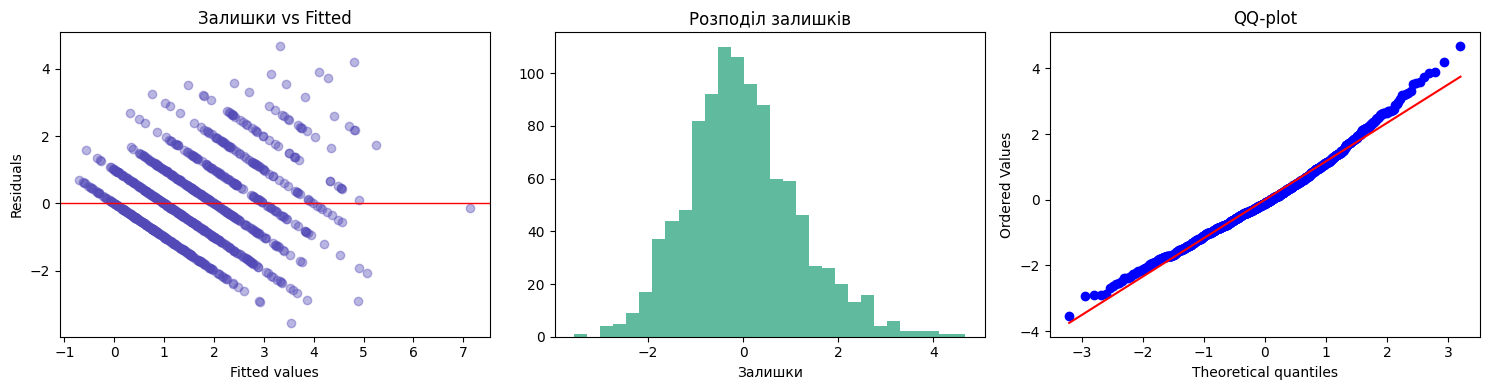

In [ ]:
lm, lm_pvalue, f, f_pvalue = het_breuschpagan(model4_sweets.resid, model4_sweets.model.exog)
print(f"Breusch-Pagan p-value: {lm_pvalue:.4f}")
print("Гетероскедастичність є" if lm_pvalue < 0.05 else "Гетероскедастичності немає")

dw = durbin_watson(model4_sweets.resid)
print(f"\nDurbin-Watson: {dw:.3f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(model4_sweets.fittedvalues, model4_sweets.resid, alpha=0.4, color="#534AB7")
axes[0].axhline(0, color="red", linewidth=1)
axes[0].set_xlabel("Fitted values")
axes[0].set_ylabel("Residuals")
axes[0].set_title("Залишки vs Fitted")

axes[1].hist(model4_sweets.resid, bins=30, color="#1D9E75", alpha=0.7)
axes[1].set_xlabel("Залишки")
axes[1].set_title("Розподіл залишків")

from scipy import stats
stats.probplot(model4_sweets.resid, plot=axes[2])
axes[2].set_title("QQ-plot")

plt.tight_layout()
plt.show()

Text(195.72222222222223, 0.5, 'Location')

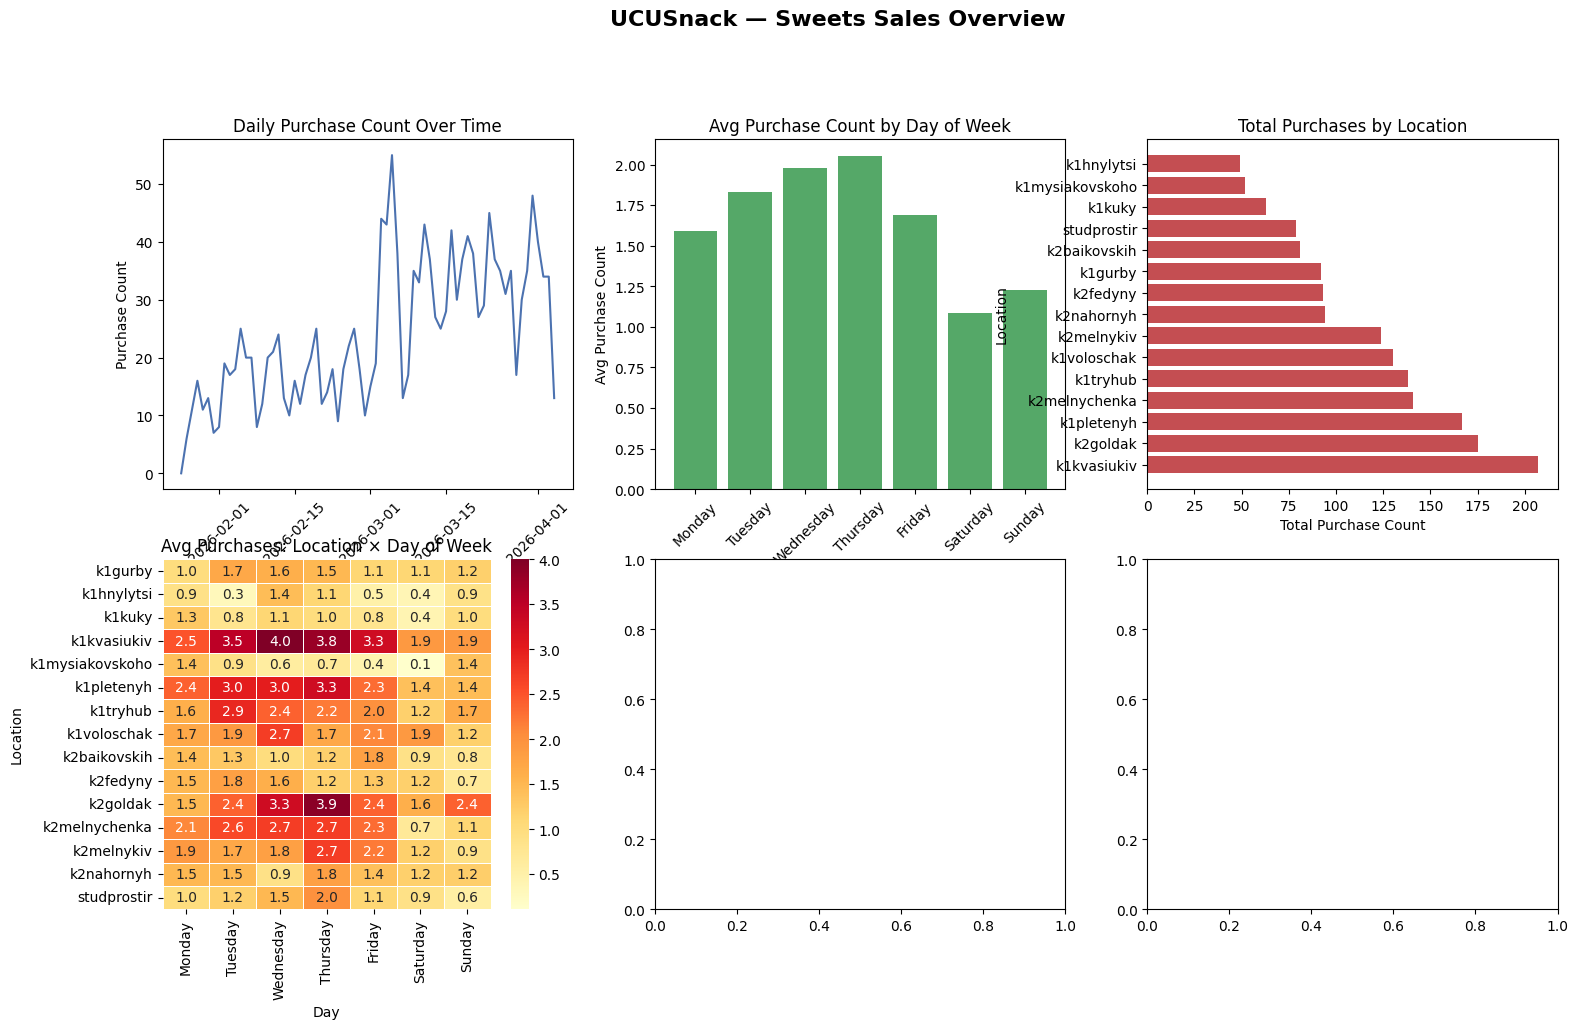

In [19]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("UCUSnack — Sweets Sales Overview", fontsize=16, fontweight="bold", y=1.01)

ax1 = axes[0, 0]
daily_total = sweets_freq.groupby("date")["purchase_count"].sum().reset_index()
ax1.plot(daily_total["date"], daily_total["purchase_count"], color="#4C72B0", linewidth=1.5)
ax1.set_title("Daily Purchase Count Over Time")
ax1.set_xlabel("Date")
ax1.set_ylabel("Purchase Count")
ax1.tick_params(axis="x", rotation=45)

ax2 = axes[0, 1]
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
day_avg = sweets_freq.groupby("day_of_week")["purchase_count"].mean().reindex(day_order)
ax2.bar(day_avg.index, day_avg.values, color="#55A868")
ax2.set_title("Avg Purchase Count by Day of Week")
ax2.set_xlabel("Day")
ax2.set_ylabel("Avg Purchase Count")
ax2.tick_params(axis="x", rotation=45)

ax3 = axes[0, 2]
loc_total = sweets_freq.groupby("store_location")["purchase_count"].sum().sort_values(ascending=False)
ax3.barh(loc_total.index, loc_total.values, color="#C44E52")
ax3.set_title("Total Purchases by Location")
ax3.set_xlabel("Total Purchase Count")
ax3.set_ylabel("Location")

ax4 = axes[1, 0]
heatmap_data = sweets_freq.pivot_table(
    index="store_location", columns="day_of_week",
    values="purchase_count", aggfunc="mean"
)[day_order]
sns.heatmap(heatmap_data, ax=ax4, cmap="YlOrRd", linewidths=0.5, annot=True, fmt=".1f")
ax4.set_title("Avg Purchases: Location × Day of Week")
ax4.set_xlabel("Day")
ax4.set_ylabel("Location")

